## Import Lib + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("googleplaystore.csv")
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


## Data Cleaning

In [3]:
# Row 10472 ("Life Made WI-Fi Touchscreen Photo Frame") is missing a Category value —
# every field after it shifted one column left, so Rating reads as an impossible 19.0.
# Confirmed single-row artifact, well-documented for this exact public dataset.
df.loc[10472]

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                               19.0
Reviews                                              3.0M
Size                                               1,000+
Installs                                             Free
Type                                                    0
Price                                            Everyone
Content Rating                                        NaN
Genres                                  February 11, 2018
Last Updated                                       1.0.19
Current Ver                                    4.0 and up
Android Ver                                           NaN
Name: 10472, dtype: object

In [4]:
df = df.drop(index=10472).reset_index(drop=True)
print(f"shape after dropping corrupted row: {df.shape}")

shape after dropping corrupted row: (10840, 13)


In [5]:
def parse_installs(s):
    return int(s.replace(",", "").replace("+", ""))

def parse_size(s):
    if s == "Varies with device":
        return np.nan
    if s.endswith("M"):
        return float(s[:-1])
    if s.endswith("k"):
        return float(s[:-1]) / 1024
    return np.nan

def parse_price(s):
    return float(s.replace("$", ""))

df["Installs_num"] = df["Installs"].apply(parse_installs)
df["Size_num"] = df["Size"].apply(parse_size)
df["Price_num"] = df["Price"].apply(parse_price)
df["Reviews_num"] = df["Reviews"].astype(float)

print(f"Size_num missing ('Varies with device', kept as an explicit NaN, not imputed): {df['Size_num'].isna().sum()} rows")

Size_num missing ('Varies with device', kept as an explicit NaN, not imputed): 1695 rows


In [6]:
print(f"duplicate App names: {df['App'].duplicated().sum()} (mostly legitimate — same app "
      "listed under multiple categories/versions, not cleaning errors)")
print(f"exact full-row duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"shape after dropping exact duplicates: {df.shape}")

duplicate App names: 1181 (mostly legitimate — same app listed under multiple categories/versions, not cleaning errors)
exact full-row duplicates: 483
shape after dropping exact duplicates: (10357, 17)


In [7]:
df["hit"] = (df["Installs_num"] >= 1_000_000).astype(int)
print(f"'hit' target (Installs >= 1,000,000): {df['hit'].mean():.1%} hit / {1 - df['hit'].mean():.1%} flop")
# kept for the "Rating vs hit" deep dive below, even though hit is not a regression feature

'hit' target (Installs >= 1,000,000): 39.1% hit / 60.9% flop


In [8]:
print(f"rows with missing Rating (target): {df['Rating'].isna().sum()}")
df = df.dropna(subset=["Rating"]).reset_index(drop=True)
print(f"shape after dropping rows with missing Rating: {df.shape}")

rows with missing Rating (target): 1465
shape after dropping rows with missing Rating: (8892, 18)


## EDA

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8892 entries, 0 to 8891
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8892 non-null   object 
 1   Category        8892 non-null   object 
 2   Rating          8892 non-null   float64
 3   Reviews         8892 non-null   object 
 4   Size            8892 non-null   object 
 5   Installs        8892 non-null   object 
 6   Type            8892 non-null   object 
 7   Price           8892 non-null   object 
 8   Content Rating  8892 non-null   object 
 9   Genres          8892 non-null   object 
 10  Last Updated    8892 non-null   object 
 11  Current Ver     8888 non-null   object 
 12  Android Ver     8890 non-null   object 
 13  Installs_num    8892 non-null   int64  
 14  Size_num        7424 non-null   float64
 15  Price_num       8892 non-null   float64
 16  Reviews_num     8892 non-null   float64
 17  hit             8892 non-null   i

In [10]:
df.describe()

,Rating,Installs_num,Size_num,Price_num,Reviews_num,hit
count,8892.000000,8.892000e+03,7424.000000,8892.000000,8.892000e+03,8892.000000
mean,4.187877,1.648965e+07,22.747273,0.963155,4.727764e+05,0.455691
std,0.522377,8.637600e+07,23.435118,16.189341,2.905052e+06,0.498061
min,1.000000,1.000000e+00,0.008301,0.000000,1.000000e+00,0.000000
25%,4.000000,1.000000e+04,5.100000,0.000000,1.640000e+02,0.000000
50%,4.300000,5.000000e+05,14.000000,0.000000,4.714500e+03,0.000000
75%,4.500000,5.000000e+06,33.000000,0.000000,7.126675e+04,1.000000
max,5.000000,1.000000e+09,100.000000,400.000000,7.815831e+07,1.000000


## Distribution Check

In [11]:
sns.set_theme(style="whitegrid")

def plot_numeric_distribution(df, col, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} — histogram")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} — boxplot")
    plt.tight_layout()
    plt.show()
    print(df[col].describe())

    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[col][(df[col] < lower) | (df[col] > upper)]
    print(f"IQR outlier bounds (1.5x rule): [{lower:.2f}, {upper:.2f}]")
    print(f"outliers: {len(outliers)} rows ({len(outliers) / df[col].notna().sum():.2%} of non-missing data)")
    if len(outliers):
        print(f"  below lower bound: {(outliers < lower).sum()}, above upper bound: {(outliers > upper).sum()}")

def plot_categorical_distribution(df, col, order=None, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    order = order or df[col].value_counts().index
    ax = sns.countplot(x=df[col], order=order)
    ax.set_title(f"{col} — value counts")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts(normalize=True).round(3))

def plot_top_categorical_distribution(df, col, top_n=20):
    top = df[col].value_counts().head(top_n)
    plt.figure(figsize=(9, 5))
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette="viridis", legend=False)
    plt.title(f"{col} — top {top_n} of {df[col].nunique()} categories by count")
    plt.xlabel("count")
    plt.tight_layout()
    plt.show()
    print(f"top {top_n} categories cover {top.sum() / len(df):.1%} of rows")


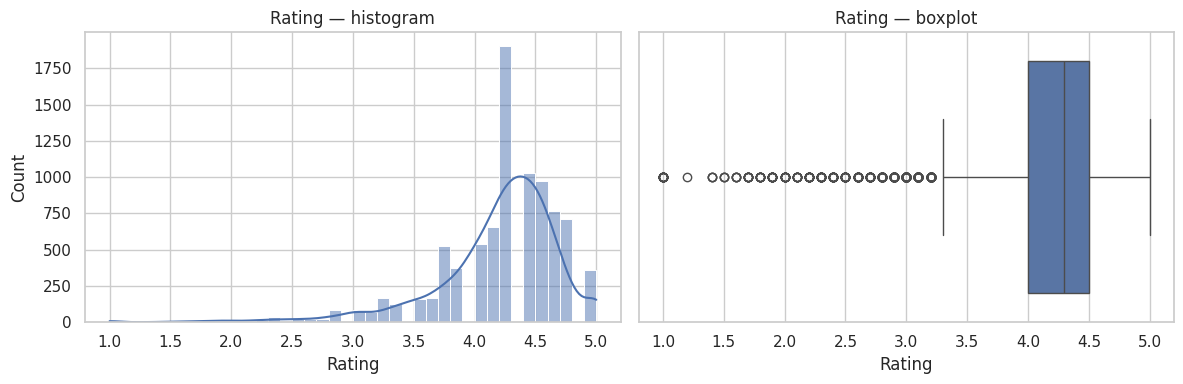

count    8892.000000
mean        4.187877
std         0.522377
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64
IQR outlier bounds (1.5x rule): [3.25, 5.25]
outliers: 495 rows (5.57% of non-missing data)
  below lower bound: 495, above upper bound: 0


In [12]:
# Rating has no missing values in this notebook — rows with missing Rating were dropped in Data Cleaning.
plot_numeric_distribution(df, "Rating")

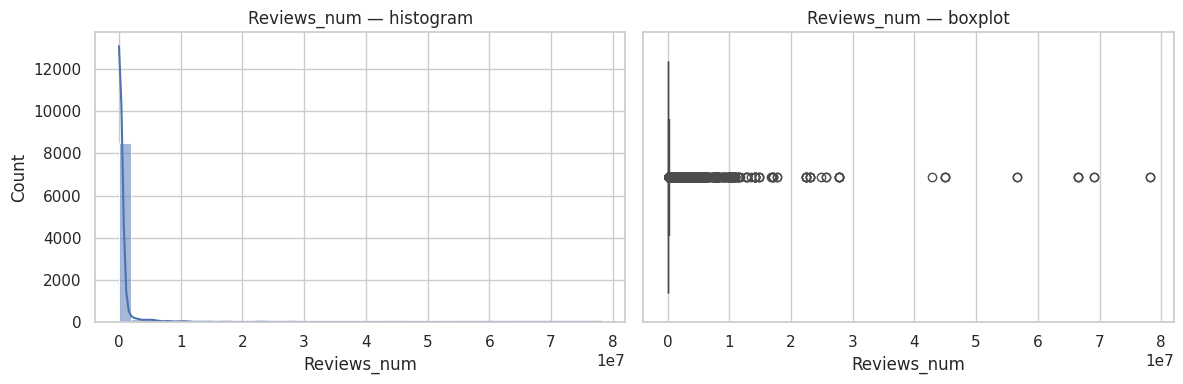

count    8.892000e+03
mean     4.727764e+05
std      2.905052e+06
min      1.000000e+00
25%      1.640000e+02
50%      4.714500e+03
75%      7.126675e+04
max      7.815831e+07
Name: Reviews_num, dtype: float64
IQR outlier bounds (1.5x rule): [-106490.12, 177920.88]
outliers: 1555 rows (17.49% of non-missing data)
  below lower bound: 0, above upper bound: 1555


In [13]:
plot_numeric_distribution(df, "Reviews_num")

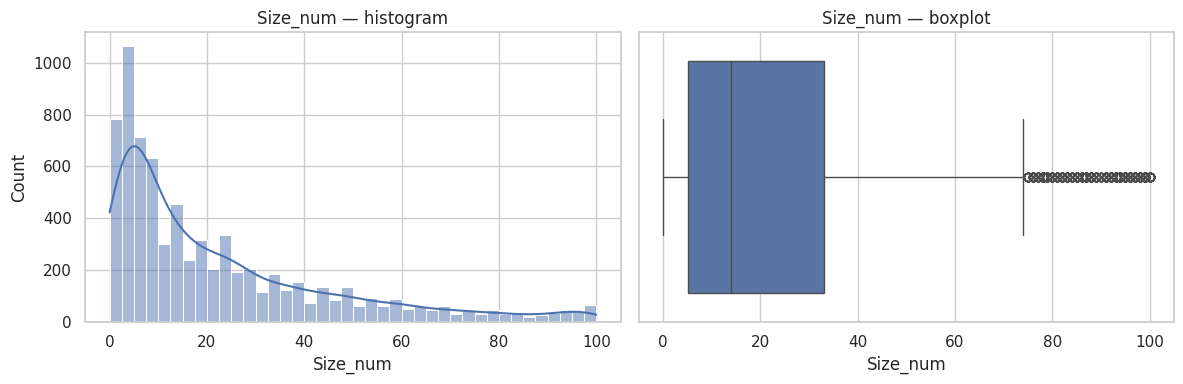

count    7424.000000
mean       22.747273
std        23.435118
min         0.008301
25%         5.100000
50%        14.000000
75%        33.000000
max       100.000000
Name: Size_num, dtype: float64
IQR outlier bounds (1.5x rule): [-36.75, 74.85]
outliers: 388 rows (5.23% of non-missing data)
  below lower bound: 0, above upper bound: 388


In [14]:
plot_numeric_distribution(df, "Size_num")

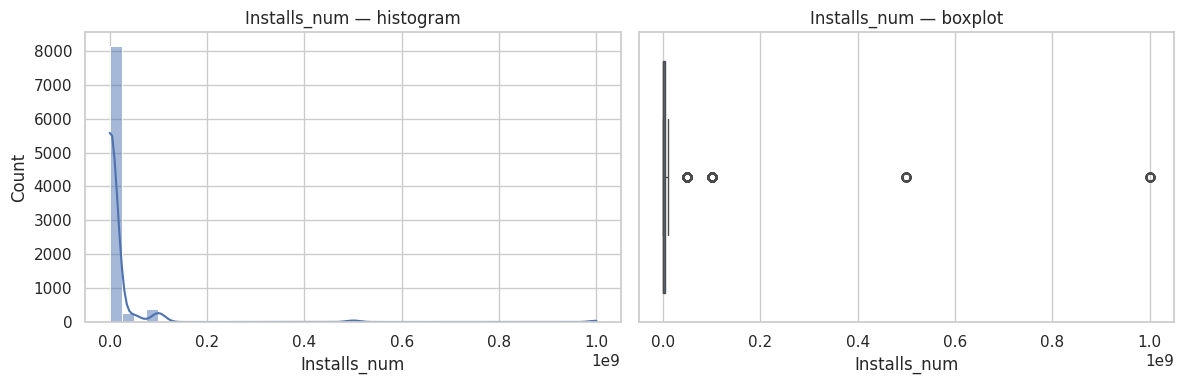

count    8.892000e+03
mean     1.648965e+07
std      8.637600e+07
min      1.000000e+00
25%      1.000000e+04
50%      5.000000e+05
75%      5.000000e+06
max      1.000000e+09
Name: Installs_num, dtype: float64
IQR outlier bounds (1.5x rule): [-7475000.00, 12485000.00]
outliers: 751 rows (8.45% of non-missing data)
  below lower bound: 0, above upper bound: 751


In [15]:
plot_numeric_distribution(df, "Installs_num")

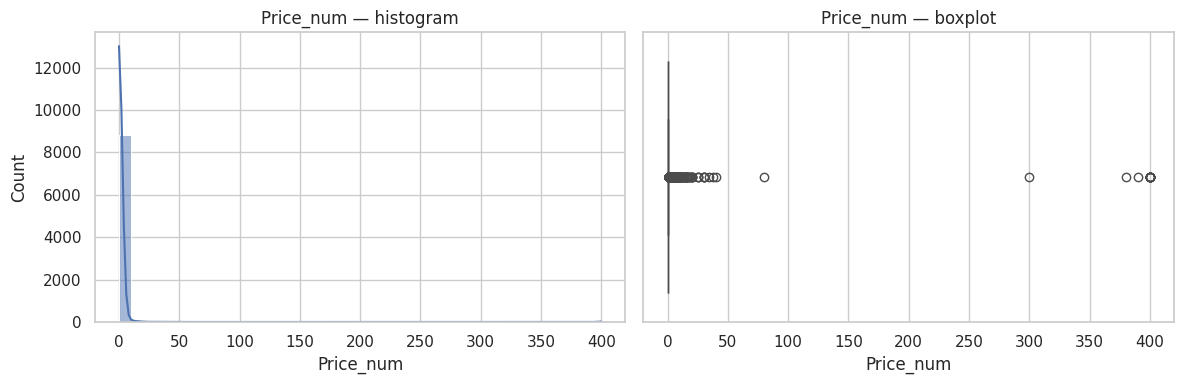

count    8892.000000
mean        0.963155
std        16.189341
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       400.000000
Name: Price_num, dtype: float64
IQR outlier bounds (1.5x rule): [0.00, 0.00]
outliers: 613 rows (6.89% of non-missing data)
  below lower bound: 0, above upper bound: 613


In [16]:
plot_numeric_distribution(df, "Price_num")

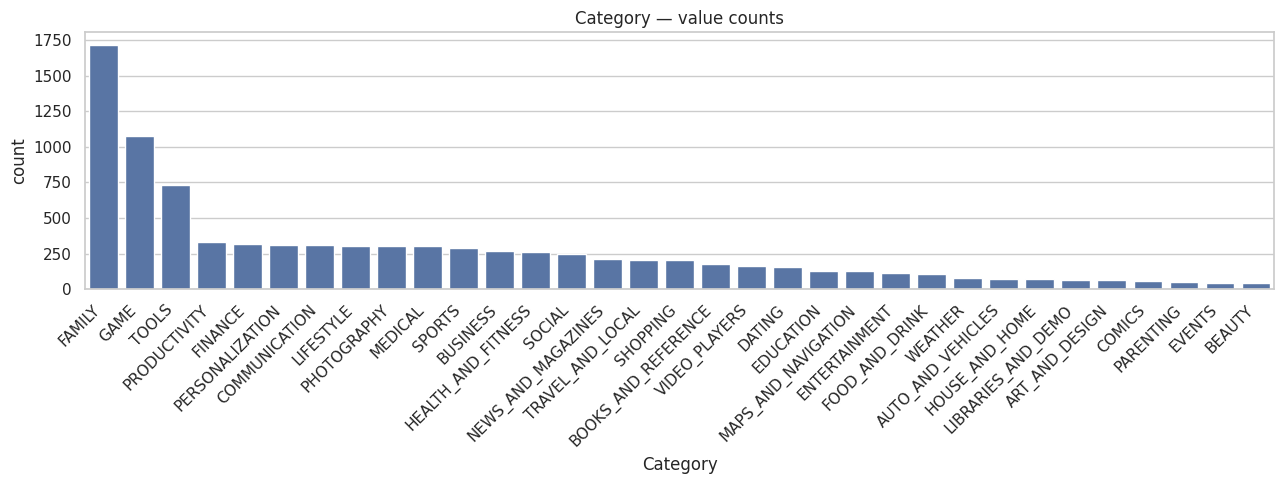

Category
FAMILY                 0.193
GAME                   0.121
TOOLS                  0.083
PRODUCTIVITY           0.038
FINANCE                0.036
PERSONALIZATION        0.035
COMMUNICATION          0.035
LIFESTYLE              0.034
PHOTOGRAPHY            0.034
MEDICAL                0.034
SPORTS                 0.032
BUSINESS               0.030
HEALTH_AND_FITNESS     0.029
SOCIAL                 0.027
NEWS_AND_MAGAZINES     0.024
TRAVEL_AND_LOCAL       0.023
SHOPPING               0.023
BOOKS_AND_REFERENCE    0.020
VIDEO_PLAYERS          0.018
DATING                 0.018
EDUCATION              0.015
MAPS_AND_NAVIGATION    0.014
ENTERTAINMENT          0.012
FOOD_AND_DRINK         0.012
WEATHER                0.008
AUTO_AND_VEHICLES      0.008
HOUSE_AND_HOME         0.008
LIBRARIES_AND_DEMO     0.007
ART_AND_DESIGN         0.007
COMICS                 0.007
PARENTING              0.006
EVENTS                 0.005
BEAUTY                 0.005
Name: proportion, dtype: float64


In [17]:
plot_categorical_distribution(df, "Category", figsize=(13, 5))

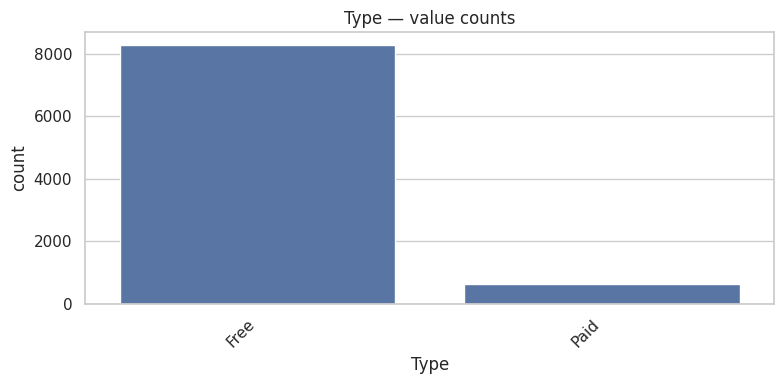

Type
Free    0.931
Paid    0.069
Name: proportion, dtype: float64


In [18]:
plot_categorical_distribution(df, "Type")

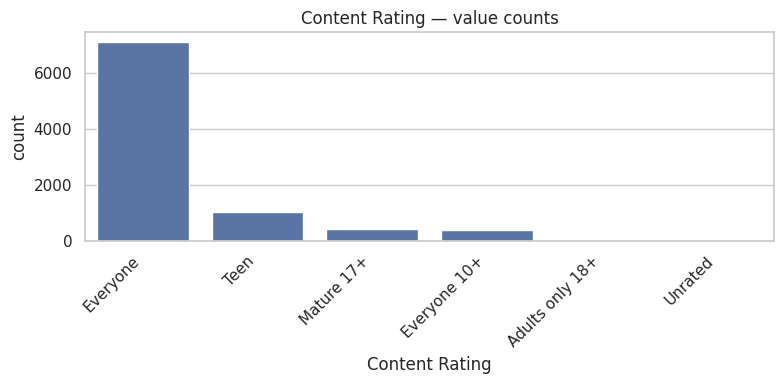

Content Rating
Everyone           0.798
Teen               0.115
Mature 17+         0.046
Everyone 10+       0.040
Adults only 18+    0.000
Unrated            0.000
Name: proportion, dtype: float64


In [19]:
plot_categorical_distribution(df, "Content Rating")

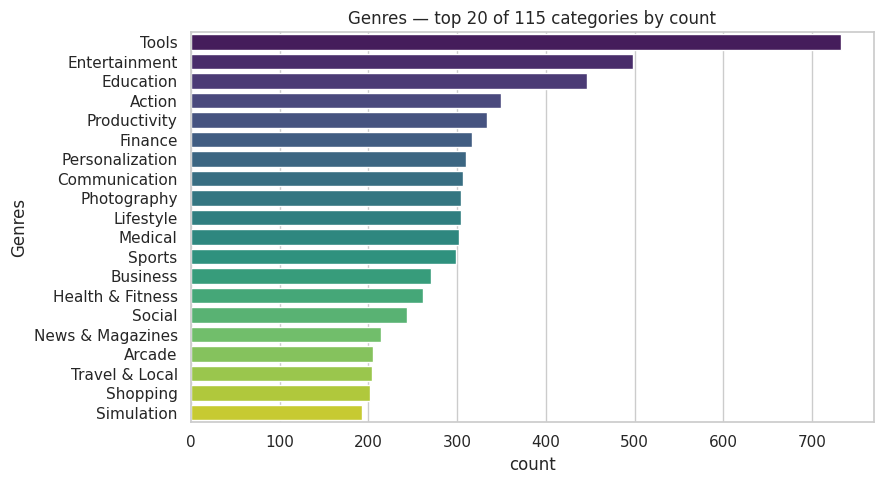

top 20 categories cover 70.8% of rows


In [20]:
plot_top_categorical_distribution(df, "Genres")

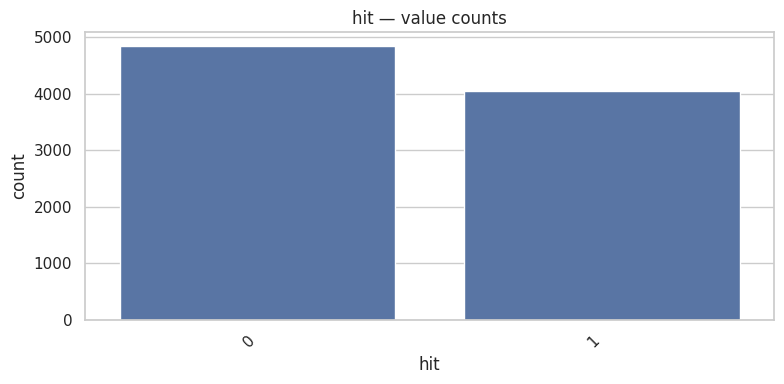

hit
0    0.544
1    0.456
Name: proportion, dtype: float64
class balance — 'hit' apps (installs >= 1,000,000): 45.6%


In [21]:
plot_categorical_distribution(df, "hit")
print(f"class balance — 'hit' apps (installs >= 1,000,000): {df['hit'].mean():.1%}")

## Regression EDA — Primary Target: Rating

In [22]:
numeric_cols = ["Reviews_num", "Size_num", "Installs_num", "Price_num"]
categorical_cols = ["Category", "Type", "Content Rating", "Genres"]

def correlation_ratio(categories, values):
    d = pd.DataFrame({"cat": categories.values, "val": values.values}).dropna()
    grand_mean = d["val"].mean()
    group_stats = d.groupby("cat")["val"].agg(["mean", "count"])
    ss_between = (group_stats["count"] * (group_stats["mean"] - grand_mean) ** 2).sum()
    ss_total = ((d["val"] - grand_mean) ** 2).sum()
    return np.sqrt(ss_between / ss_total)

relevance_reg = {}
for col in numeric_cols:
    relevance_reg[col] = abs(df[col].corr(df["Rating"]))
for col in categorical_cols:
    relevance_reg[col] = correlation_ratio(df[col], df["Rating"])

relevance_reg = pd.Series(relevance_reg).sort_values(ascending=False)
relevance_reg_df = relevance_reg.rename("relevance_score").to_frame()
relevance_reg_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in relevance_reg_df.index]
relevance_reg_df

,relevance_score,type
Genres,0.200458,categorical
Category,0.170397,categorical
Size_num,0.081969,numeric
Reviews_num,0.068732,numeric
Content Rating,0.050940,categorical
Installs_num,0.050886,numeric
Type,0.038353,categorical
Price_num,0.022355,numeric


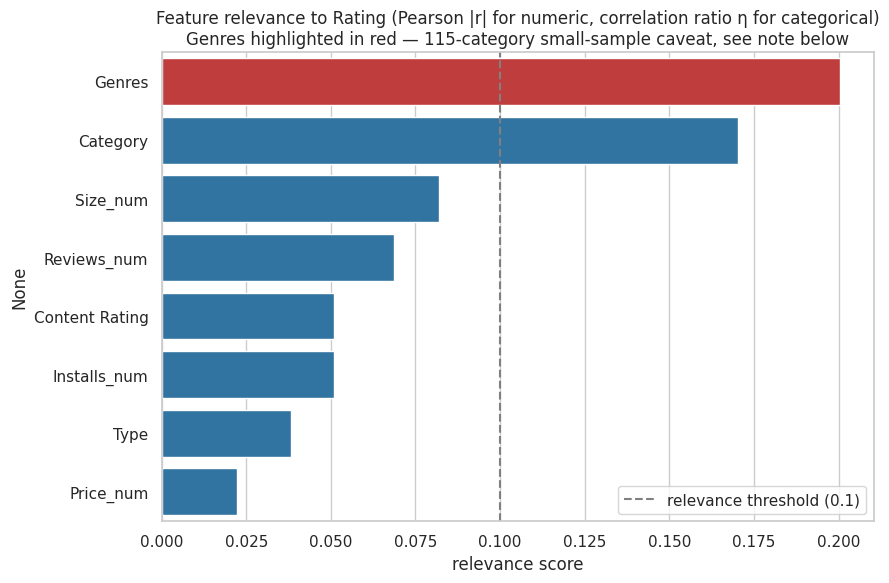

features clearing relevance threshold (0.1): ['Genres', 'Category']
caveat: Genres has 115 categories on ~8,900 rows — correlation ratio η is a known-biased statistic on sparse categories (small groups inflate between-group variance), so this score is flagged, not taken at face value. Category (33 groups, reasonable group sizes) is the more trustworthy categorical signal.


In [23]:
plt.figure(figsize=(9, 6))
colors = ["#d62728" if c == "Genres" else "#1f77b4" for c in relevance_reg.index]
sns.barplot(x=relevance_reg.values, y=relevance_reg.index, hue=relevance_reg.index, palette=colors, legend=False)
plt.axvline(0.1, color="gray", linestyle="--", label="relevance threshold (0.1)")
plt.title("Feature relevance to Rating (Pearson |r| for numeric, correlation ratio η for categorical)\nGenres highlighted in red — 115-category small-sample caveat, see note below")
plt.xlabel("relevance score")
plt.legend()
plt.tight_layout()
plt.show()

RELEVANCE_THRESHOLD = 0.1
top_features_reg = relevance_reg[relevance_reg >= RELEVANCE_THRESHOLD].index.tolist()
print(f"features clearing relevance threshold ({RELEVANCE_THRESHOLD}): {top_features_reg}")
print("caveat: Genres has 115 categories on ~8,900 rows — correlation ratio η is a known-biased "
      "statistic on sparse categories (small groups inflate between-group variance), so this score "
      "is flagged, not taken at face value. Category (33 groups, reasonable group sizes) is the "
      "more trustworthy categorical signal.")

Rating vs. other numeric features (Pearson r):
Size_num        0.082
Reviews_num     0.069
Installs_num    0.051
Price_num      -0.022
dtype: float64


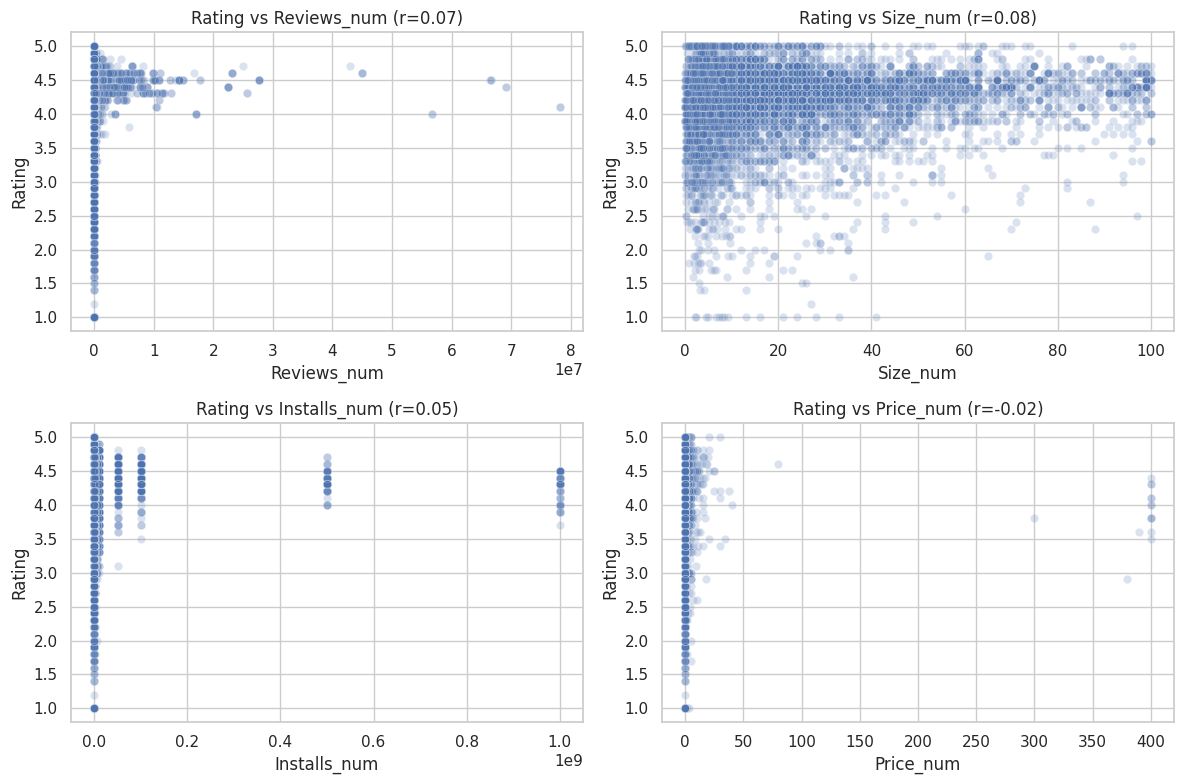

In [24]:
rating_corr = df[numeric_cols].corrwith(df["Rating"]).sort_values(key=abs, ascending=False)
print("Rating vs. other numeric features (Pearson r):")
print(rating_corr.round(3))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.scatterplot(x=df[col], y=df["Rating"], alpha=0.2, ax=ax)
    ax.set_title(f"Rating vs {col} (r={rating_corr[col]:.2f})")
plt.tight_layout()
plt.show()

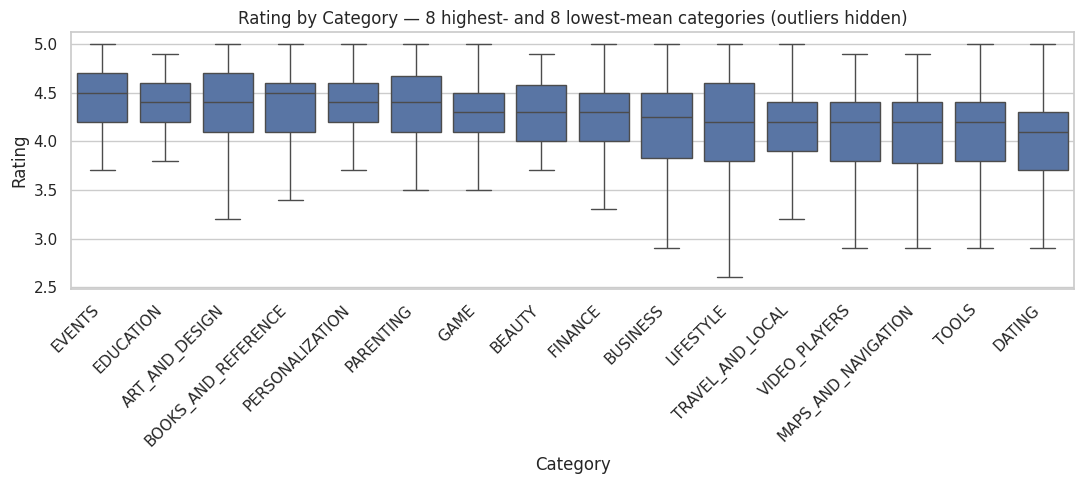

,mean,count
Category,,
EVENTS,4.435556,45
EDUCATION,4.375969,129
ART_AND_DESIGN,4.358065,62
BOOKS_AND_REFERENCE,4.347458,177
PERSONALIZATION,4.333871,310
PARENTING,4.300000,50
GAME,4.281285,1074
BEAUTY,4.278571,42
HEALTH_AND_FITNESS,4.261450,262


In [25]:
cat_stats = df.groupby("Category")["Rating"].agg(["mean", "count"]).sort_values("mean", ascending=False)
top_bottom = pd.concat([cat_stats.head(8), cat_stats.tail(8)])
order = top_bottom.index
mask = df["Category"].isin(order)

plt.figure(figsize=(11, 5))
sns.boxplot(x=df.loc[mask, "Category"], y=df.loc[mask, "Rating"], order=order, showfliers=False)
plt.title("Rating by Category — 8 highest- and 8 lowest-mean categories (outliers hidden)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

cat_stats

### Discussion — Rating

## Multicollinearity (numeric feature-to-feature)

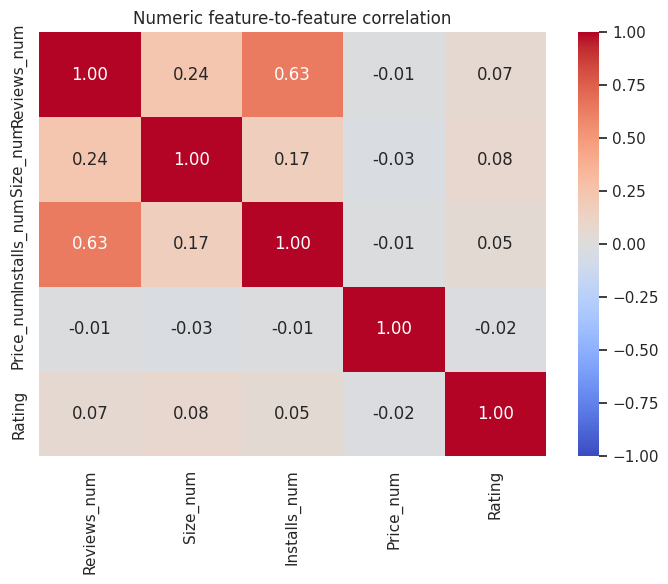

In [26]:
numeric_cols_full = numeric_cols + ["Rating"]
corr_matrix = df[numeric_cols_full].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Numeric feature-to-feature correlation")
plt.tight_layout()
plt.show()

## Deep Dive — Rating vs hit

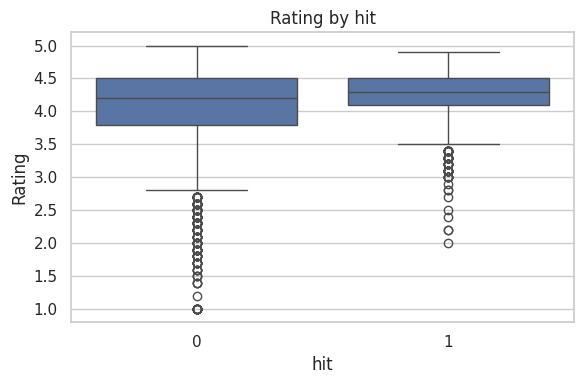

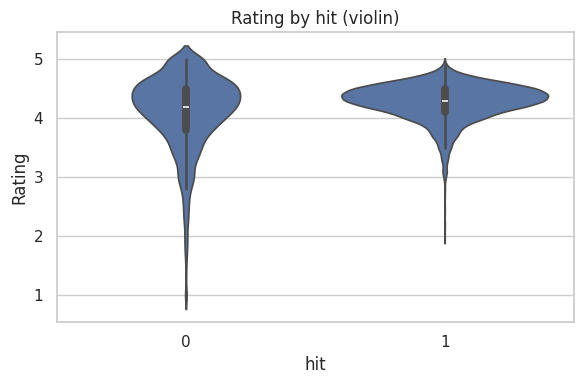

,median,mean,count
hit,,,
0,4.2,4.113120,4840
1,4.3,4.277172,4052


In [27]:
def plot_numeric_vs_target(df, col, target="hit"):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"{col} by {target}")
    plt.tight_layout()
    plt.show()

plot_numeric_vs_target(df, "Rating")

fig, ax = plt.subplots(figsize=(6, 4))
sns.violinplot(x=df["hit"], y=df["Rating"], ax=ax)
ax.set_title("Rating by hit (violin)")
plt.tight_layout()
plt.show()

rating_by_hit = df.groupby("hit")["Rating"].agg(["median", "mean", "count"])
rating_by_hit

## Model-Based Feature Importance (RF)

In [28]:
def build_feature_matrix(df, num_cols, cat_cols):
    X_num = df[num_cols].copy()
    for c in num_cols:
        X_num[c] = X_num[c].fillna(X_num[c].median())
    frames = [X_num]
    col_to_parent = {c: c for c in num_cols}
    for col in cat_cols:
        dummies = pd.get_dummies(df[col].fillna("__missing__"), prefix=col)
        frames.append(dummies)
        col_to_parent.update({d: col for d in dummies.columns})
    return pd.concat(frames, axis=1), col_to_parent

X_reg, col_to_parent_reg = build_feature_matrix(df, numeric_cols, categorical_cols)
rf_reg = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg, df["Rating"])

importances_reg = pd.Series(rf_reg.feature_importances_, index=X_reg.columns)
importances_reg_agg = importances_reg.groupby(col_to_parent_reg).sum().sort_values(ascending=False)
importances_reg_agg

Reviews_num       0.317069
Size_num          0.237521
Genres            0.170394
Category          0.122068
Installs_num      0.098424
Content Rating    0.026871
Price_num         0.021388
Type              0.006265
dtype: float64

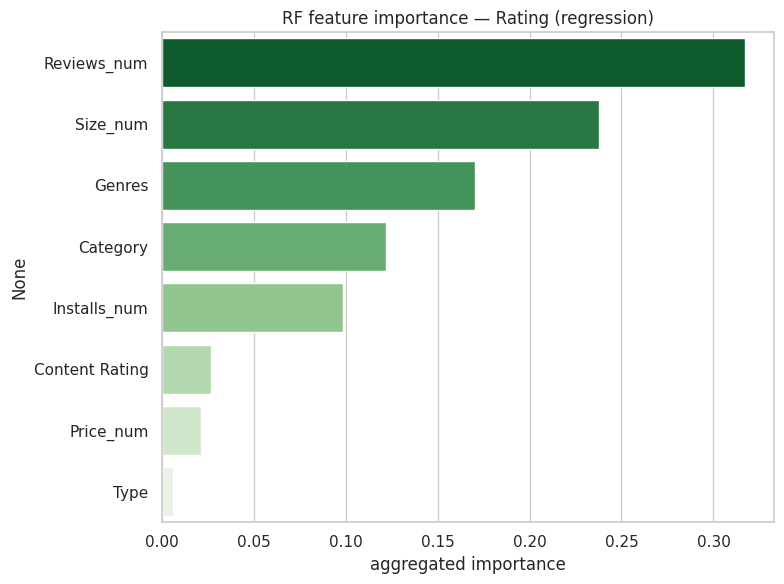

In [29]:
plt.figure(figsize=(8, 6))
sns.barplot(x=importances_reg_agg.values, y=importances_reg_agg.index, hue=importances_reg_agg.index,
            palette="Greens_r", legend=False)
plt.title("RF feature importance — Rating (regression)")
plt.xlabel("aggregated importance")
plt.tight_layout()
plt.show()

## Relevance Cross-Check — Mutual Information

In [30]:
from sklearn.feature_selection import mutual_info_regression

mi_numeric = pd.Series(
    mutual_info_regression(X_reg[numeric_cols], df["Rating"], discrete_features=False, random_state=42),
    index=numeric_cols,
)

cat_codes = df[categorical_cols].fillna("__missing__").apply(lambda s: pd.factorize(s)[0])
mi_categorical = pd.Series(
    mutual_info_regression(cat_codes, df["Rating"], discrete_features=True, random_state=42),
    index=categorical_cols,
)

mi_relevance = pd.concat([mi_numeric, mi_categorical]).sort_values(ascending=False)
mi_relevance_df = mi_relevance.rename("mutual_info").to_frame()
mi_relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in mi_relevance_df.index]
mi_relevance_df

,mutual_info,type
Reviews_num,0.298588,numeric
Installs_num,0.180585,numeric
Genres,0.105030,categorical
Category,0.061769,categorical
Size_num,0.042750,numeric
Price_num,0.008747,numeric
Content Rating,0.002360,categorical
Type,0.000000,categorical


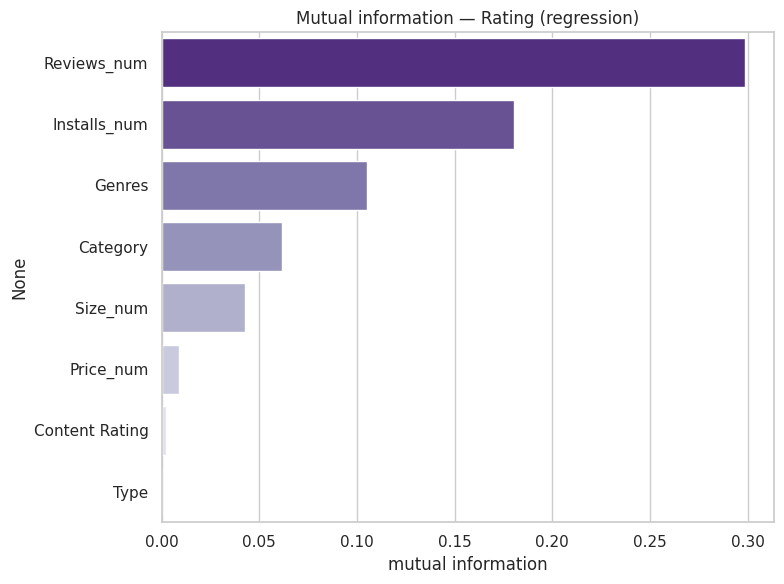

In [31]:
plt.figure(figsize=(8, 6))
sns.barplot(x=mi_relevance.values, y=mi_relevance.index, hue=mi_relevance.index,
            palette="Purples_r", legend=False)
plt.title("Mutual information — Rating (regression)")
plt.xlabel("mutual information")
plt.tight_layout()
plt.show()